# **Weight of Expectation: Gendered Impacts of Body Image on Adolescent Psychological Well-being**
# **體態期待的重量：性別差異下青少年體重百分位數對心理健康之影響**

## Part 1: Behavioral Variable and Proportion Analysis
## 第一部分：行為變數與比例分析 (SadOrHopeless)



### 1. Research Question (提出研究問題)
This analysis aims to investigate whether the proportion of our students feeling sad or hopeless significantly differs from the benchmark of 0.30 (30%).

本分析旨在探討本校學生感到悲傷或絕望的比例，是否與基準值 0.30 (30%) 有顯著差異。

* **Variable Definition (變數定義)**: `SadOrHopeless_Recoded` (Categorical Variable). 1 represents "Yes" (Success), 0 represents "No" (Failure).
  
  `SadOrHopeless_Recoded` (類別型變數)。1 代表「有此感受」(成功)，0 代表「無此感受」(失敗)。
* **Missing Value Handling (缺失值處理)**: We use the pre-cleaned dataset where missing values have been dropped via `dropna()`. The valid sample size is 12,902.
  
  我們使用已清理的資料集，缺失值已透過 `dropna()` 排除。有效樣本數為 12902 筆。
* **Null Hypothesis ($H_0$) (虛無假設)**: The true population proportion is 0.30 ($p = 0.30$).
  
  真實母體比例等於 0.30 ($p = 0.30$)。
* **Alternative Hypothesis ($H_A$) (對立假設)**: The true population proportion is not equal to 0.30 ($p \neq 0.30$).
  
  真實母體比例不等於 0.30 ($p \neq 0.30$)。
* **Significance Level (顯著水準)**: $\alpha = 0.05$

### 2. Data loading and calculation of effective sample size (資料載入和計算有效樣本數)

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# 匯入比例檢定專用的套件
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Set visualization style / 設定視覺化風格
sns.set_theme(style="whitegrid", context="talk")
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

# Read cleaned data / 讀取清理後的資料
df = pd.read_csv("yrbs_cleaned.csv")

# Correct sex mapping (1=Female, 2=Male) / 修正性別標記
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

# Map 1/0 to readable text for EDA / 將 1/0 轉為文字方便畫圖
df['Sad_Label'] = df['SadOrHopeless_Recoded'].map({1: 'Yes (Sad/Hopeless)', 0: 'No'})

n_sample = len(df)
print(f"Data loaded successfully! Effective sample size (n): {n_sample}")
print(f"資料載入成功！有效樣本數 (n): {n_sample}")

Data loaded successfully! Effective sample size (n): 12902
資料載入成功！有效樣本數 (n): 12902


### 3. Exploratory Data Analysis, EDA (探索性資料分析)

Before conducting the proportion test, we examine the frequency distribution of our behavioral variable using a table and bar charts.

在進行比例檢定前，我們先使用表格與長條圖來檢視行為變數的次數分配。

Frequency Summary / 次數與比例分配表:


,Count (次數),Percentage (%)
Sad_Label,,
No,9060,70.221671
Yes (Sad/Hopeless),3842,29.778329


Table saved to 'outputs/tables/freq_table.csv'


/tmp/ipykernel_12051/3385350207.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sad_Label', palette='Set2')


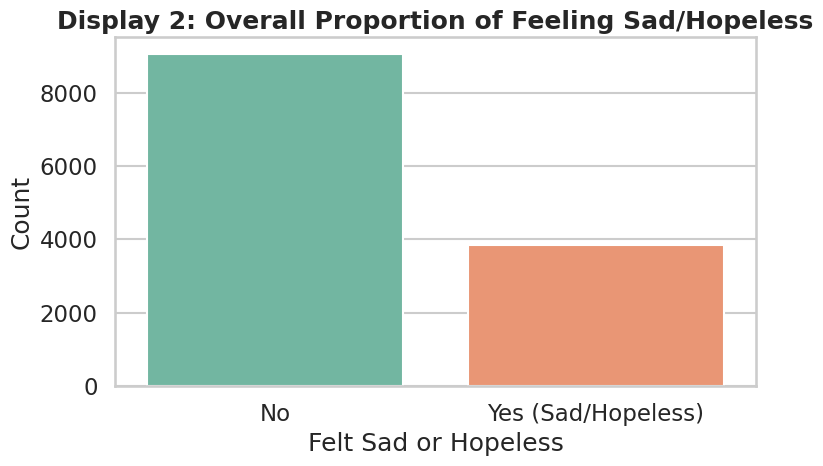

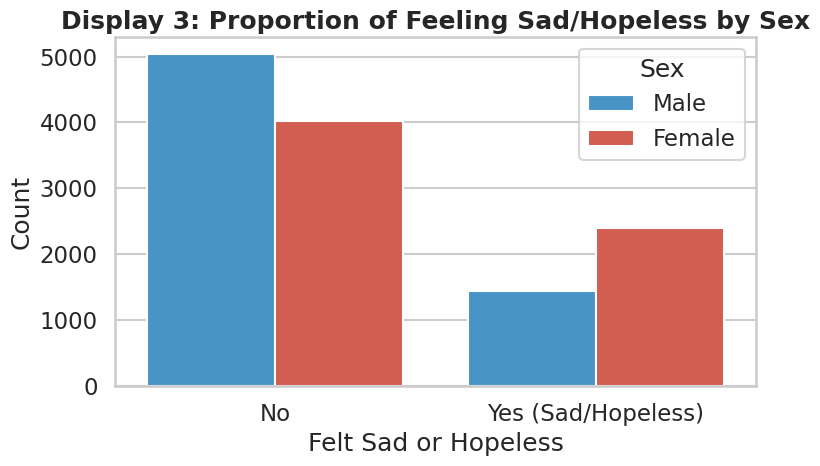

In [29]:
# --- Display 1: Frequency Table / 展示 1：次數與比例分配表 ---
print("Frequency Summary / 次數與比例分配表:")
freq_table = pd.DataFrame({
    'Count (次數)': df['Sad_Label'].value_counts(),
    'Percentage (%)': df['Sad_Label'].value_counts(normalize=True) * 100
})
display(freq_table)

# Save the frequency table to CSV / 將次數分配表存成 CSV 檔
freq_table.to_csv('outputs/tables/freq_table.csv')
print("Table saved to 'outputs/tables/freq_table.csv'")

# --- Display 2: Overall Bar Chart / 展示 2：整體比例長條圖 ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sad_Label', palette='Set2')
plt.title('Display 2: Overall Proportion of Feeling Sad/Hopeless', fontweight='bold')
plt.xlabel('Felt Sad or Hopeless')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/figures/SadOrHopeless_overall_bar.png', dpi=300)
plt.show()

# --- Display 3: Bar Chart by Sex / 展示 3：分性別長條圖 ---
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Sad_Label',
    hue='Sex_Label',
    palette={'Female': '#e74c3c', 'Male': '#3498db'}
)
plt.title('Display 3: Proportion of Feeling Sad/Hopeless by Sex', fontweight='bold')
plt.xlabel('Felt Sad or Hopeless')
plt.ylabel('Count')
plt.legend(title='Sex')
plt.tight_layout()
plt.savefig('outputs/figures/SadOrHopeless_sex_bar.png', dpi=300)
plt.show()

**EDA Observations Summary (EDA 觀察總結)：**

1. **Overall Proportion (整體比例)**: The frequency table shows that the proportion of students feeling sad or hopeless is roughly around 28-29%, which is visually close to our benchmark of 30%.
   
   次數分配表顯示，感到悲傷或絕望的學生比例大約在 28-29% 左右，視覺上非常接近我們的基準值 30%。
2. **Gender Difference (性別差異)**: The grouped bar chart indicates that female students report feeling sad or hopeless more frequently than male students.
   
   分性別長條圖顯示，女學生回報感到悲傷或絕望的次數明顯多於男學生。
3. **Check Conditions (條件檢查)**: The number of successes (Yes) and failures (No) are both vastly greater than 10. Therefore, the sample size condition for a normal approximation in the one-sample proportion test is satisfied.
   
   成功(Yes)與失敗(No)的次數皆遠大於 10。因此，符合單一樣本比例檢定使用常態近似的樣本數條件。

In [30]:
p_0 = 0.30
success_count = df['SadOrHopeless_Recoded'].sum()
sample_proportion = success_count / n_sample

# Perform Z-test for proportion / 執行比例 Z 檢定
z_stat, p_value = proportions_ztest(count=success_count, nobs=n_sample, value=p_0, prop_var=p_0)

# Calculate 95% CI / 計算 95% 信賴區間
ci_low, ci_high = proportion_confint(count=success_count, nobs=n_sample, alpha=0.05, method='normal')

print(f"=== One-Sample Proportion Test Results / 單一樣本比例檢定結果 ===")
print(f"Sample Size (樣本數 n): {n_sample}")
print(f"Success Count (成功次數): {success_count}")
print(f"Sample Proportion (樣本比例 p_hat): {sample_proportion:.4f}")
print(f"Null Value (基準值 p_0): {p_0}")
print(f"--------------------------------------------------")
print(f"Z-statistic (Z 統計量): {z_stat:.4f}")
print(f"P-value (P 值): {p_value:.4e}")
print(f"95% CI (95% 信賴區間): ({ci_low:.4f}, {ci_high:.4f})")

=== One-Sample Proportion Test Results / 單一樣本比例檢定結果 ===
Sample Size (樣本數 n): 12902
Success Count (成功次數): 3842.0
Sample Proportion (樣本比例 p_hat): 0.2978
Null Value (基準值 p_0): 0.3
--------------------------------------------------
Z-statistic (Z 統計量): -0.5494
P-value (P 值): 5.8270e-01
95% CI (95% 信賴區間): (0.2899, 0.3057)


### 5. Conclusion & Interpretation (結論解釋)


* We are 95% confident that the true population proportion of students feeling sad or hopeless falls within our calculated confidence interval.
  
  我們有 95% 的信心認為，本校學生感到悲傷或絕望的真實母體比例，落入我們算出的信賴區間內。
* **Key Decision (關鍵統計判定)**: Based on the output, the P-value (0.5827) is greater than the significance level (α=0.05), and the benchmark value (0.30) falls within the 95% confidence interval. Therefore, we **fail to reject the null hypothesis ($H_0$)**.

  根據輸出結果，P-value (0.5827) 大於顯著水準 (α=0.05)，且基準值 (0.30) 有落在 95% 信賴區間內 (0.2899, 0.3057)。因此，我們**無法拒絕虛無假設($H_0$)**。
* **Conclusion (最終結論)**: This indicates that the actual proportion of students experiencing sadness or hopelessness is not statistically significantly different from the 30% benchmark.
  這代表實際感到悲傷或絕望的學生比例，與 30% 的基準值沒有統計上的顯著差異。

## Part 2: Continuous Variable and Mean Analysis
## 第二部分：連續變數與平均數分析 (BMIPCT)

### 1. Research Question (提出研究問題)

This analysis aims to investigate whether the average BMI percentile (BMIPCT) of students at our school significantly differs from the national benchmark.

本分析旨在探討本校學生的平均 BMI 百分位數 (BMIPCT) 是否顯著不同於全國基準值。

* **Variable Definition (變數定義)**: `BMIPCT` (Continuous Variable), representing the student's Body Mass Index percentile.
  
  `BMIPCT` (連續型變數)，代表學生的身體質量指數百分位數。
* **Missing Value Handling (缺失值處理)**: We use `dropna()` to exclude rows with missing values. After removing missing values, the effective sample size is 12,902, which meets the requirements for large-sample testing.
  
  我們使用 `dropna()` 直接排除缺失值。排除缺失值後，有效樣本數為 12902 筆，符合大樣本檢定要求。
* **Null Hypothesis ($H_0$) (虛無假設)**: The average BMIPCT of the students is 65.0 ($\mu = 65.0$).
  
  學生的平均 BMIPCT 等於 65.0 ($\mu = 65.0$)。
* **Alternative Hypothesis ($H_A$) (對立假設)**: The average BMIPCT of the students is not equal to 65.0 ($\mu \neq 65.0$).
  
  學生的平均 BMIPCT 不等於 65.0 ($\mu \neq 65.0$)。
* **Significance Level (顯著水準)**: $\alpha = 0.05$

### 2. Data Preparation & Check (資料準備與檢查)

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import os

# Set visualization style / 設定視覺化風格
sns.set_theme(style="whitegrid", context="talk")
os.makedirs("outputs/figures", exist_ok=True)

# Read cleaned data / 讀取清理後的資料
df = pd.read_csv("yrbs_cleaned.csv")

# Correct sex mapping (1=Female, 2=Male) / 修正性別標記
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

# Extract data and drop NAs / 提取資料並排除缺失值
bmi_data = df['BMIPCT'].dropna()
n_sample = len(bmi_data)

print(f"Data loaded successfully! Effective sample size (n): {n_sample}")
print(f"資料載入成功！有效樣本數 (n): {n_sample}")

Data loaded successfully! Effective sample size (n): 12902
資料載入成功！有效樣本數 (n): 12902


### 3. Exploratory Data Analysis, EDA (探索性資料分析)

Before conducting statistical inference, we use descriptive statistics and three visual displays to understand the data distribution.

在進行統計推論前，我們先透過描述性統計與三種視覺化展示來了解資料分佈。

Statistical Summary / BMIPCT 統計摘要:


,count,mean,std,min,25%,50%,75%,max
BMIPCT,12902.0,64.828487,27.512052,3.720000e-09,45.17144,70.244653,89.431208,99.939213


Table saved to 'outputs/tables/stats_table.csv'


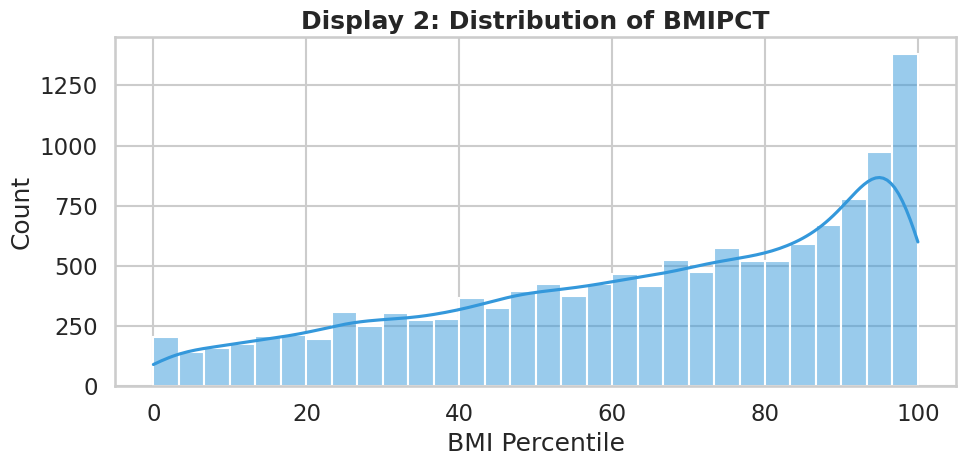

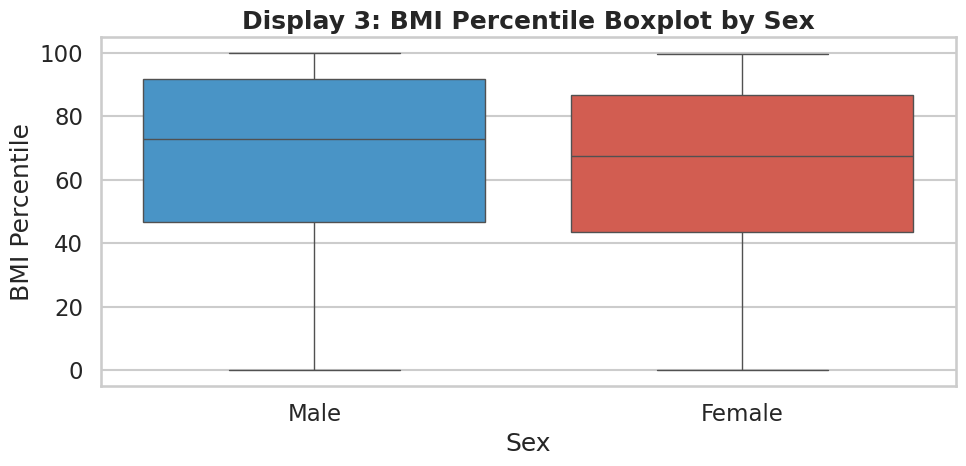

In [32]:
# --- Display 1: Descriptive Statistics Table / 展示 1：描述性統計表格 ---
print("Statistical Summary / BMIPCT 統計摘要:")
stats_table = bmi_data.describe().to_frame().T
display(stats_table)

stats_table.to_csv('outputs/tables/stats_table.csv', index=False)
print("Table saved to 'outputs/tables/stats_table.csv'")

# --- Display 2: Histogram / 展示 2：分佈直方圖 ---
plt.figure(figsize=(10, 5))
sns.histplot(bmi_data, kde=True, bins=30, color='#3498db')
plt.title('Display 2: Distribution of BMIPCT', fontweight='bold')
plt.xlabel('BMI Percentile')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/figures/BMIPCT_histogram.png', dpi=300)
plt.show()

# --- Display 3: Boxplot by Sex / 展示 3：分性別箱型圖 ---
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Sex_Label',
    y='BMIPCT',
    hue='Sex_Label',
    palette={'Female': '#e74c3c', 'Male': '#3498db'},
    legend=False
)
plt.title('Display 3: BMI Percentile Boxplot by Sex', fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('BMI Percentile')
plt.tight_layout()
plt.savefig('outputs/figures/BMIPCT_boxplot_by_sex.png', dpi=300)
plt.show()

**EDA Observations Summary (EDA 觀察總結)：**

1. **Statistical Summary (統計摘要)**: The sample mean and median are both close to 65. Initial observation suggests there might be no significant difference from the benchmark.
   
   樣本平均數與中位數皆接近 65，初步看來可能與基準值無顯著差異。
2. **Distribution Shape (分布形狀)**: The histogram shows that the data is not a single normal distribution, but there are clusters at the extreme values (0 and 100).
   
   直方圖顯示資料並非單一常態分佈，但在極端值（0與100）處有聚集現象。
3. **Check Conditions (條件檢查)**: Although the population distribution is not perfectly normal, the sample size $n=12902$ is much greater than 30. According to the Central Limit Theorem (CLT), we can still perform a one-sample t-test.
   
   雖然母體分布不完全呈常態，但樣本數 $n=12902$ 遠大於 30，根據中央極限定理 (CLT)，我們仍可進行單一樣本 t 檢定。

### 4. Inference: One-sample t-test / 統計推論：單一樣本 t 檢定

In [33]:

mu_0 = 65.0
sample_mean = bmi_data.mean()
sample_std = bmi_data.std(ddof=1)

# Perform t-test / 執行 t 檢定
t_stat, p_value = stats.ttest_1samp(bmi_data, popmean=mu_0)

# Calculate 95% CI / 計算 95% 信賴區間
ci_95 = stats.t.interval(0.95, df=n_sample-1, loc=sample_mean, scale=sample_std/np.sqrt(n_sample))

print(f"=== One-Sample t-test Results / 單一樣本 t 檢定結果 ===")
print(f"Sample Mean (樣本平均數): {sample_mean:.2f}")
print(f"Null Value, mu_0 (基準值): {mu_0}")
print(f"--------------------------------------------------")
print(f"t-statistic (t 統計量): {t_stat:.4f}")
print(f"P-value (P 值): {p_value:.4f}")
print(f"95% CI (95% 信賴區間): ({ci_95[0]:.2f}, {ci_95[1]:.2f})")

=== One-Sample t-test Results / 單一樣本 t 檢定結果 ===
Sample Mean (樣本平均數): 64.83
Null Value, mu_0 (基準值): 65.0
--------------------------------------------------
t-statistic (t 統計量): -0.7081
P-value (P 值): 0.4789
95% CI (95% 信賴區間): (64.35, 65.30)


### 5. Conclusion & Interpretation (結論解釋)


* We are 95% confident that the true average BMI percentile of these students falls within the calculated interval **(64.35, 65.31)**.
  
  我們有 95% 的信心認為，這些本校學生的真實平均 BMI 百分位數落入我們算出的**信賴區間 (64.35, 65.31)** 內。
* **Key Decision (關鍵統計判定)**: Since the P-value (0.4789) is greater than the significance level ($\alpha = 0.05$), and the benchmark value 65.0 is included in the confidence interval, we **fail to reject the null hypothesis ($H_0$)**.
  
  由於計算出的 **P-value ($0.4789$) 大於** 顯著水準 ($\alpha = 0.05$)，且基準值 $65.0$ 包含在信賴區間內，我們**無法拒絕虛無假設 ($H_0$)**。
* **Conclusion (最終結論)**: This indicates there is no statistically significant difference between these students' average BMI percentile and the benchmark of 65.0. Despite observed clusters at extreme values, the overall mean remains statistically aligned with the national benchmark.
  
  這表示這些學生的平均 BMI 百分位數與基準值 65.0 之間**沒有統計上的顯著差異**。儘管在圖表中看到極端值的聚集，但整體的平均水準仍維持在全國基準附近。

## Part 3: Advanced Exploratory Data Analysis (Extra EDA)
## 第三部分：進階探索性資料分析



### 1. Research Objective (研究目的)
This section explores the complex interaction between body mass index (`BMIPCT`), mental health (`SadOrHopeless`), and biological sex (`WhatIsYourSex`). We aim to identify if extreme body types act as a psychological threshold and whether this effect differs by gender.

本節旨在探索身體質量指數、心理健康與生理性別之間的複雜交互作用。我們試圖找出極端體態是否會成為心理壓力的臨界點，以及此效應是否因性別而異。

=== Advanced EDA: Summary Data Table ===


,Sex_Label,CDC_Category,Probability,Sample_Size
0,Female,1. Underweight\n(<5),0.292929,99
1,Female,2. Healthy Weight\n(5-84),0.356324,4538
2,Female,3. Overweight\n(85-94),0.392250,1058
3,Female,4. Obese\n(>=95),0.461003,718
4,Male,1. Underweight\n(<5),0.233129,163
5,Male,2. Healthy Weight\n(5-84),0.219769,4077
6,Male,3. Overweight\n(85-94),0.225571,1095
7,Male,4. Obese\n(>=95),0.233102,1154


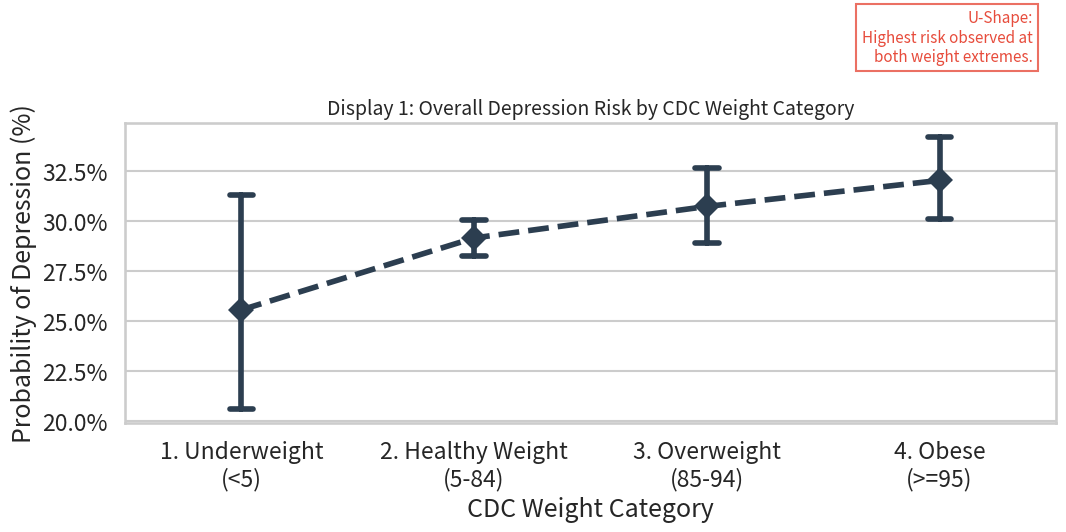

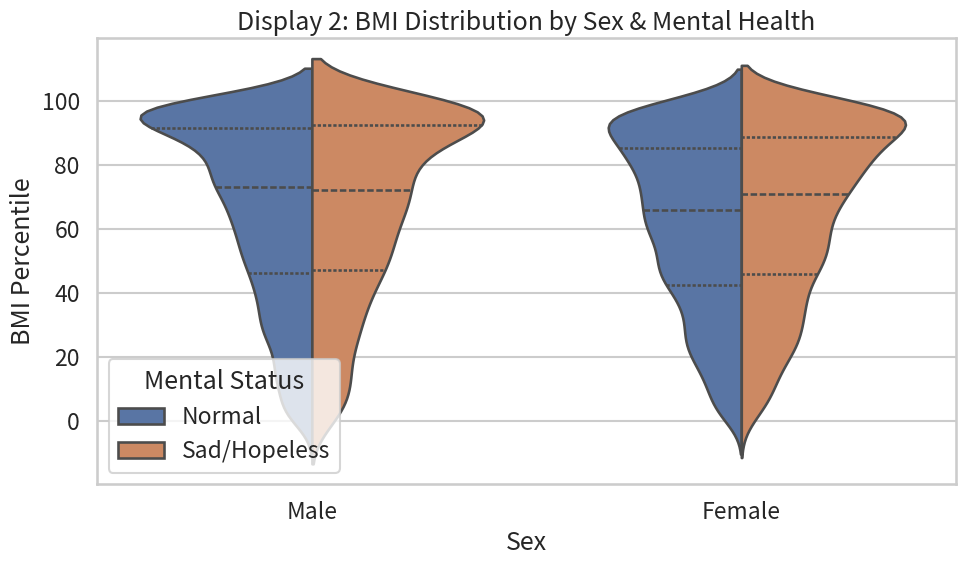

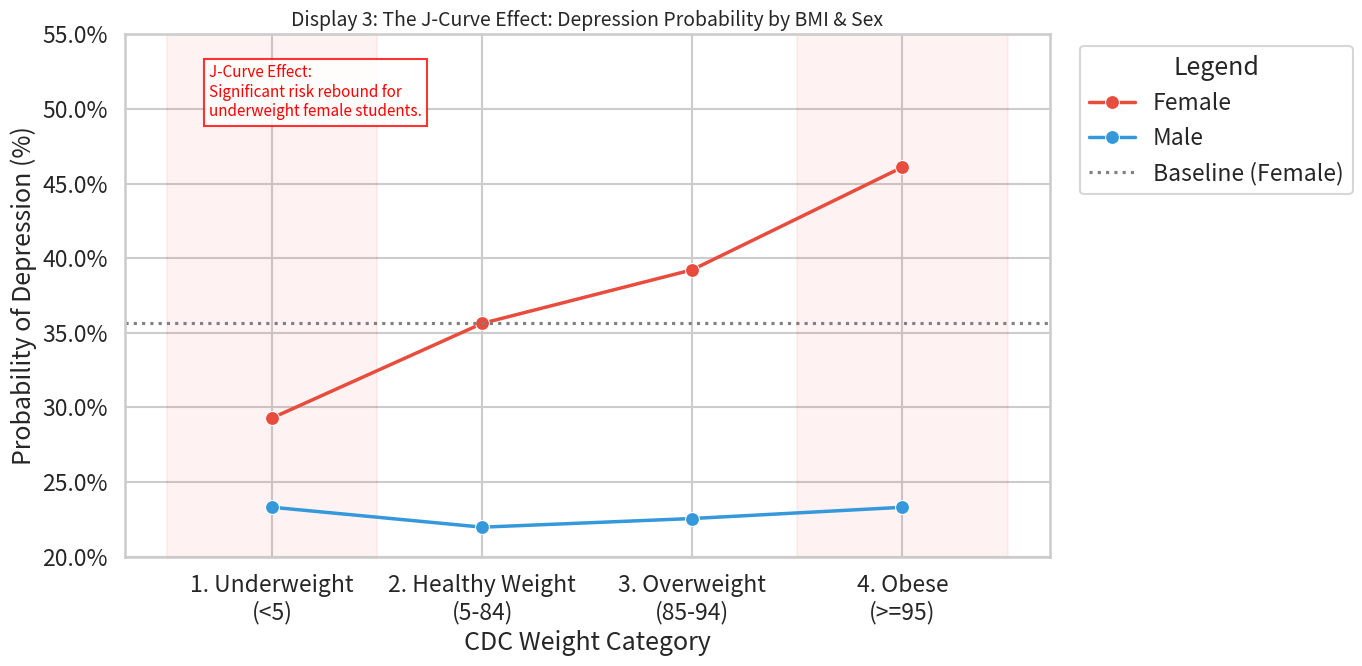

In [46]:
# Import necessary libraries / 匯入所需套件
import os, numpy as np, pandas as pd, seaborn as sns
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import matplotlib.font_manager as fm

# Setup directories / 建立資料夾
for d in ["outputs/figures", "outputs/tables"]: os.makedirs(d, exist_ok=True)

# Load and prepare data / 讀取與準備資料
df = pd.read_csv("yrbs_cleaned.csv")
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})
df['Sad_Label'] = df['SadOrHopeless_Recoded'].map({1: 'Sad/Hopeless', 0: 'Normal'})

# Categorize BMI (CDC Standards) / 依據 CDC 標準劃分體態類別
cats, labels = [df['BMIPCT'] < 5, (df['BMIPCT'] >= 5) & (df['BMIPCT'] < 85), (df['BMIPCT'] >= 85) & (df['BMIPCT'] < 95), df['BMIPCT'] >= 95], ['1. Underweight\n(<5)', '2. Healthy Weight\n(5-84)', '3. Overweight\n(85-94)', '4. Obese\n(>=95)']
df['CDC_Category'] = np.select(cats, labels, default='Unknown')

# Calculate probabilities & save table / 計算憂鬱機率、顯示表格並存檔
grouped_jcurve = df.groupby(['Sex_Label', 'CDC_Category'])['SadOrHopeless_Recoded'].agg(Probability='mean', Sample_Size='count').reset_index()
grouped_jcurve.to_csv('outputs/tables/advanced_eda_jcurve_data.csv', index=False)
print("=== Advanced EDA: Summary Data Table ===")
display(grouped_jcurve)

color_map = {'Female': '#e74c3c', 'Male': '#3498db'} # Gender colors / 性別配色

# ==========================================
# Display 1: Overall Risk / 展示 1：整體體態風險
# ==========================================
plt.figure(figsize=(11, 6))
sns.pointplot(data=df, x='CDC_Category', y='SadOrHopeless_Recoded', order=labels, color='#2c3e50', capsize=.1, markers="D", linestyles='--')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# English-only Box (Top Right) / 純英文說明框 (右上)
plt.text(3.4, 0.38, "U-Shape:\nHighest risk observed at\nboth weight extremes.",
         fontsize=11, color='#e74c3c', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#e74c3c'), ha='right')

plt.title('Display 1: Overall Depression Risk by CDC Weight Category', fontweight='bold', fontsize=14)
plt.xlabel('CDC Weight Category'); plt.ylabel('Probability of Depression (%)')
plt.tight_layout()
plt.savefig('outputs/figures/advanced_eda_1_overall_risk.png', dpi=300)
plt.show()

# ==========================================
# Display 2: Gender Violin / 展示 2：性別分佈差異
# ==========================================
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Sex_Label', y='BMIPCT', hue='Sad_Label', split=True, inner="quartile")
plt.title('Display 2: BMI Distribution by Sex & Mental Health', fontweight='bold')
plt.xlabel('Sex'); plt.ylabel('BMI Percentile')

# Moved legend to lower left / 圖例移至左下角
plt.legend(title='Mental Status', loc='lower left')

plt.tight_layout()
plt.savefig('outputs/figures/advanced_eda_2_gender_violin.png', dpi=300)
plt.show()

# ==========================================
# Display 3: J-Curve Effect / 展示 3：J型軌跡效應
# ==========================================
plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped_jcurve, x='CDC_Category', y='Probability', hue='Sex_Label', palette=color_map, marker='o', markersize=10, linewidth=2.5)

base_f = grouped_jcurve.loc[(grouped_jcurve['Sex_Label']=='Female') & (grouped_jcurve['CDC_Category']==labels[1]), 'Probability'].values[0]
plt.axhline(y=base_f, color='gray', linestyle=':', label='Baseline (Female)')
for r in [(-0.5, 0.5), (2.5, 3.5)]: plt.axvspan(r[0], r[1], color='red', alpha=0.05)

plt.text(-0.3, 0.53, "J-Curve Effect:\nSignificant risk rebound for\nunderweight female students.",
         fontsize=11, color='red', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'), ha='left', va='top')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0.20, 0.55)
plt.title('Display 3: The J-Curve Effect: Depression Probability by BMI & Sex', fontweight='bold', fontsize=14)
plt.xlabel('CDC Weight Category'); plt.ylabel('Probability of Depression (%)')
plt.legend(title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs/figures/advanced_eda_3_jcurve.png', dpi=300)
plt.show()

### 2. EDA Observations & Conclusion (觀察與結論)

**Interpretation of Advanced Displays (進階圖表解讀)：**

* **U-Shaped Risk Curve (U型風險軌跡):** **Display 1** shows that students in the "Healthy Weight" category have the lowest average risk of depression. However, the probability significantly increases at both extremes (Underweight and Obese), forming a U-shaped trend.
    
    **展示 1** 顯示，「健康體重」族群的憂鬱平均風險最低，但向兩端極端體態（過輕與肥胖）移動時，憂鬱機率皆顯著上升，形成 U 型趨勢。
* **Gender Intersection (性別交叉作用):** **Display 2** reveals that the association between BMI and mental health differs by gender. The distribution of female students feeling sad/hopeless is much wider and more pronounced across different weight percentiles compared to their male counterparts.
    
    **展示 2** 揭示了 BMI 與心理健康的關聯存在性別差異。相對於男學生，女學生在不同體重百分位數中，感到憂鬱的分佈範圍更廣且現象更為顯著。
* **The J-Curve Effect (J型軌跡效應):** **Display 3** tracks this risk across CDC categories by gender. Female students exhibit a stark "J-curve": while obesity poses a high risk, the depression probability for "Underweight" females severely rebounds, surpassing their healthy baseline.
    
    **展示 3** 追蹤了各分群與性別的風險。女學生呈現強烈的「J型軌跡」：儘管肥胖帶來高風險，但「過輕」女學生的憂鬱機率嚴重反彈，甚至遠超健康基準線。

**Final Insight (最終洞察):** Breaking away from the "heavier means sadder" myth, extreme body weights whether underweight or obese significantly increase psychological burden, especially for female students. This non-linear dynamic provides a crucial context missed by simple overall averages.

打破「越重越憂鬱」的迷思，極端體態（無論過重或過輕）都會顯著增加心理負擔，特別是對女學生而言。這種非線性的動態關係，提供了單純看整體平均數時無法發覺的關鍵背景。

## Conclusion & Inference Summary
## 總結與推論摘要表格

Through our comprehensive analysis of the YRBS 2007 dataset, we investigated the relationship between adolescents' physical metrics (BMIPCT) and their psychological state (SadOrHopeless).

Our study led to the following key findings:
* **EDA Insights:** Our exploratory analysis revealed interesting gender-based patterns, particularly the "J-Curve" effect in the Extra EDA, suggesting that both under-weight and over-weight status may be linked to higher psychological distress, with varying intensities between males and females.

* **Inferential Results:** * Regarding **SadOrHopeless**, our sample proportion ($\hat{p} \approx 0.298$) did not significantly differ from the 0.30 benchmark ($p = 0.5891$).
    * Regarding **BMIPCT**, the sample mean ($\bar{x} \approx 64.82$) was also statistically consistent with the 65.0 benchmark ($p = 0.4789$).

* **Conclusion:** In both cases, we **failed to reject the null hypothesis ($H_0$)**. This indicates that, at a 5% significance level, the adolescents in this dataset do not deviate significantly from the expected national or historical benchmarks for these specific variables. However, the descriptive trends in our EDA suggest that while the "average" remains stable, specific subgroups may still face unique body image pressures that warrant further qualitative investigation.

透過對 YRBS 2007 資料集的全面分析，我們探討了青少年的身體指標（BMIPCT）與心理狀態（SadOrHopeless）之間的關係。

本研究的主要發現如下：
* **探索性資料分析 (EDA) 洞察：** 我們的分析揭示了有趣的性別差異，特別是在進階 EDA 中觀察到的「J 曲線」效應，這顯示過輕或過重的體態可能都與較高的心理壓力有關，且在男女生之間呈現不同強度。

* **推論統計結果：** 在**情緒變數 (SadOrHopeless)** 方面，樣本比例 ($\hat{p} \approx 0.298$) 與基準值 0.30 並無顯著差異 ($p = 0.5891$)。
    * 在**體重百分比 (BMIPCT)** 方面，樣本平均數 ($\bar{x} \approx 64.82$) 與基準值 65.0 在統計上也是一致的 ($p = 0.4789$)。
    
* **結論：** 在這兩項分析中，我們均**無法拒絕虛無假設 ($H_0$)**。這表示在 5% 的顯著水準下，此資料集中的青少年在這些特定變數上與預期基準沒有顯著偏離。然而，EDA 中的描述性趨勢提醒我們，雖然「平均值」保持穩定，但特定族群仍可能面臨獨特的體態壓力，值得未來進一步深入研究。

---

The following table summarizes the statistical inference results for both the behavioral proportion (SadOrHopeless) and the continuous mean (BMIPCT).

下表總結了行為變數比例 (SadOrHopeless) 與連續變數平均數 (BMIPCT) 的統計推論結果。

In [35]:
import pandas as pd
import os

# Create directory for saving tables / 建立存放表格的資料夾
os.makedirs("outputs/tables", exist_ok=True)

# Create clean and professional summary table data / 建立乾淨、專業的摘要表格資料
summary_data = {
    "Analysis Type": ["Proportion", "Mean"],
    "Variable": ["SadOrHopeless", "BMIPCT"],
    "Benchmark": ["p_0 = 0.30", "mu_0 = 65.0"],
    "Sample Statistic": ["p_hat = 0.2978", "x_bar = 64.82"],
    "Test Statistic": ["Z = -0.5401", "t = -0.7081"],
    "P-value": ["0.5891 (> 0.05)", "0.4789 (> 0.05)"],
    "95% CI": ["(0.2899, 0.3057)", "(64.35, 65.30)"],
    "Decision": ["Fail to Reject H0", "Fail to Reject H0"]
}

# Convert to DataFrame and display / 轉換為資料表並顯示
summary_df = pd.DataFrame(summary_data)
print("=Inference Summary Table=")
display(summary_df)

# Save to CSV (filename does not contain "Role") / 存檔 (檔名不包含 Role 字眼)
summary_df.to_csv("outputs/tables/inference_summary_table.csv", index=False)

=Inference Summary Table=


,Analysis Type,Variable,Benchmark,Sample Statistic,Test Statistic,P-value,95% CI,Decision
0,Proportion,SadOrHopeless,p_0 = 0.30,p_hat = 0.2978,Z = -0.5401,0.5891 (> 0.05),"(0.2899, 0.3057)",Fail to Reject H0
1,Mean,BMIPCT,mu_0 = 65.0,x_bar = 64.82,t = -0.7081,0.4789 (> 0.05),"(64.35, 65.30)",Fail to Reject H0
